# Agrupamiento (*Clustering*)

La agricultura mexicana enfrenta una paradoja estructural, mientras el país cuenta con una enorme diversidad productiva, la distribución del riesgo agrícola es profundamente desigual entre municipios. Algunos territorios acumulan pérdidas crónicas de cultivos año tras año, mientras otros muestran resiliencia sostenida frente a los mismos fenómenos climáticos. Esta heterogeneidad no es aleatoria ya que responde a patrones estructurales de escala productiva, dependencia hídrica y diversificación de cultivos que pueden identificarse mediante técnicas de aprendizaje no supervisado.

Este módulo corresponde a la fase de **agrupamiento no supervisado** del proyecto integrador. Cuyo objetivo es segmentar los **2,458 municipios productores de México** en perfiles diferenciados de vulnerabilidad agrícola, utilizando 15 años de datos históricos (2010–2024) del Sistema de Información Agroalimentaria y Pesquera (SIAP). Los perfiles identificados complementan los hallazgos del EDA y enriquecen el contexto del modelo supervisado desarrollado en `modelo_supervisado.ipynb`.

In [1]:
#| echo: false
#| output: false
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")
sys.path.insert(0, '..')

import pandas as pd
from src.clustering import AgroClusteringPipeline

In [2]:
#| echo: false
#| output: false

# Cargar dataset limpio (exportado por el EDA)
RUTA_PROCESADO = '../data/processed/siap_procesado.csv'
df_clean = pd.read_csv(RUTA_PROCESADO)

print(f" {df_clean.shape[0]:,} registros, {df_clean.shape[1]} columnas")

 541,829 registros, 26 columnas


## Preparación de los datos para clustering

Para identificar perfiles de vulnerabilidad agrícola a nivel municipal, es necesario transformar el dataset ya limpio (541,829 registros a nivel cultivo-municipio-año) en una matriz donde **cada fila represente un municipio** y **cada columna sea una característica** que describe su comportamiento agrícola histórico.

Trabajar con la granularidad original de cultivo-año-municipio no es adecuado para el clustering porque un mismo municipio podría tener un año con sequía severa y otro con lluvia normal, o cultivos muy vulnerables junto con otros resilientes. La vulnerabilidad estructural (dependencia de temporal, escala productiva, diversificación) es una propiedad del territorio a lo largo del tiempo, no de una combinación específica de cultivo y año. Además, variables como `proporción_siniestro_total` o `prop_temporal` solo tienen sentido agregado a nivel municipal, ya que resumen el comportamiento histórico de cada municipio. Por estas razones, el pipeline ejecuta automáticamente la agregación mediante los siguientes pasos:

1. **Agregación municipal**: Combina todos los registros de cada municipio (usando `Nomestado` + `Nommunicipio`) sumando hectáreas, volúmenes y valores.
2. **Filtrado**: Excluye municipios con superficie sembrada total menor a 0.1 hectáreas (considerados inactivos).
3. **Cálculo de variables derivadas**:
   - `Sembrada_total`: Escala productiva del municipio (hectáreas acumuladas)
   - `proporcion_siniestro_total`: Riesgo histórico = Siniestrada_total / Sembrada_total
   - `prop_temporal`: Exposición climática = superficie de temporal / superficie total
   - `Rendimiento_medio`: Productividad física promedio (ton/ha)
   - `Precio_medio`: Valor comercial promedio ($/ton)
   - `Diversidad_cultivos`: Resiliencia ecológica (número de cultivos distintos)

Una vez obtenida esta matriz municipal, el pipeline continúa con las siguientes etapas (que se detallan en las secciones posteriores):

4. **Transformación logarítmica** (`log1p`) para reducir el sesgo positivo de variables como superficie, rendimiento y precio.
5. **Escalamiento estándar** (`StandardScaler`) para que todas las variables tengan el mismo peso en el cálculo de distancias.
6. **Reducción de dimensionalidad con PCA** (opcional pero útil para visualización).
7. **Ajuste del algoritmo K-Means** para identificar los perfiles de vulnerabilidad.

In [3]:
#| echo: false
#| output: false
pipeline = AgroClusteringPipeline(random_state=42)
df_mun = pipeline.preprocesar_y_agregar(df_clean)
df_mun.head()

2458 municipios procesados.


,Nomestado,Nommunicipio,Sembrada_total,Siniestrada_total,Cosechada_total,Volumen_total,Valor_total,Area_temporal_total,Precio_medio,Rendimiento_medio,Diversidad_cultivos,proporcion_siniestro_total,prop_temporal,log_Sembrada_total,log_Rendimiento_medio,log_Precio_medio,log_Diversidad_cultivos
0,Aguascalientes,Aguascalientes,420867.24,54043.0,364198.94,8909912.80,6.399227e+09,294693.75,4554.578652,28.176157,36,0.128409,0.700206,12.950075,3.373352,8.424108,3.610918
1,Aguascalientes,Asientos,293087.52,22946.0,269709.42,5250674.10,9.455611e+09,185090.80,4753.454377,26.851044,40,0.078291,0.631521,12.588230,3.326870,8.466837,3.713572
2,Aguascalientes,Calvillo,152380.99,6313.0,144275.54,2181675.94,8.876646e+09,48481.33,5980.043592,21.861102,35,0.041429,0.318159,11.934146,3.129437,8.696350,3.583519
3,Aguascalientes,Cosío,87948.68,7293.0,80236.98,1643006.38,2.785027e+09,40149.55,4169.692263,23.251737,32,0.082923,0.456511,11.384520,3.188488,8.335837,3.496508
4,Aguascalientes,El Llano,314461.99,68964.0,245038.70,2075886.34,1.518034e+09,298156.85,4698.888475,22.569559,27,0.219308,0.948149,12.658622,3.159956,8.455294,3.332205


## Justificación de las Variables Seleccionadas y Preprocesamiento

El agrupamiento K-Means agrupa observaciones basándose en la geometría y distancias de sus atributos. Para caracterizar el perfil de vulnerabilidad agrícola municipal, se seleccionaron las siguientes 6 variables agregadas por municipio, cada una justificando un aspecto operativo del sector:

1. **`log_Sembrada_total` (Escala Productiva):** Es el logaritmo de la superficie total sembrada. Distingue entre municipios de agricultura a gran escala y aquellos de agricultura familiar o de subsistencia.
2. **`proporcion_siniestro_total` (Riesgo de Pérdida Histórico):** Es la proporción de hectáreas siniestradas respecto a las sembradas ($\text{Siniestrada\_total} / \text{Sembrada\_total}$). Es la variable central de riesgo.
3. **`prop_temporal` (Dependencia Climática):** Proporción del área sembrada bajo la modalidad de temporal. La agricultura de temporal depende de las lluvias, lo que la hace altamente vulnerable a sequías e inundaciones extremas, a diferencia de las zonas con infraestructura de riego.
4. **`log_Rendimiento_medio` (Productividad Física):** Representa el promedio de toneladas cosechadas por hectárea. Identifica la eficiencia productiva de la tierra.
5. **`log_Precio_medio` (Valor Económico):** El precio medio de los cultivos comercializados en el municipio, reflejando el acceso al mercado y el valor comercial de su producción.
6. **`log_Diversidad_cultivos` (Mitigación por Diversificación):** Número de cultivos únicos registrados. La diversidad de cultivos es una estrategia de resiliencia frente a plagas y fluctuaciones climáticas.

### Justificación del Preprocesamiento Matemático
* **Transformación Logarítmica (`log1p`):** Variables como el área sembrada, el rendimiento y el precio presentan un sesgo positivo severo (pocos municipios masivos dominan los valores máximos). Al aplicar $f(x) = \ln(1 + x)$, se comprime el sesgo y se estabiliza la varianza.
* **Normalización Estándar (`StandardScaler`):** K-Means calcula distancias Euclidianas:
  $$d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{j=1}^{d} (x_j - y_j)^2}$$
  Si las variables no se normalizan, una variable con un rango amplio (como `Sembrada_total`) dominará el cálculo de distancias sobre una acotada como `proporcion_siniestro_total` (que va de 0 a 1). La normalización a media 0 y desviación estándar 1 asegura que cada variable tenga el mismo peso en el 
  espacio geométrico.

> **Nota sobre la elección del escalador frente a outliers:** El EDA documentó valores extremos en Rendimiento (máximo ~10 millones) y Precio (máximo ~2,048,000 pesos/ton). Se eligió `StandardScaler` en lugar de `RobustScaler` porque la transformación `log1p` aplicada previamente ya comprime estos extremos: por ejemplo, log1p(10,000,000) ≈ 16.1, un valor que no domina desproporcionadamente el cálculo de distancias frente al resto de variables. La normalización estándar posterior garantiza que todas las variables tengan el mismo peso geométrico en el espacio de K-Means.

In [4]:
#| echo: false
X_scaled = pipeline.escalar_datos()
print(f"Variables de clustering preprocesadas: {pipeline.features_cols}")
print(f"Forma de la matriz de entrada a K-Means: {X_scaled.shape}")

Variables de clustering preprocesadas: ['log_Sembrada_total', 'proporcion_siniestro_total', 'prop_temporal', 'log_Rendimiento_medio', 'log_Precio_medio', 'log_Diversidad_cultivos']
Forma de la matriz de entrada a K-Means: (2458, 6)


## Determinación del Número Óptimo de Clústeres ($K$)

Evaluamos K-Means en el rango $K \in [2, 10]$ utilizando dos criterios de optimización matemática:

1. **Método del Codo (Within-Cluster Sum of Squares - WCSS):** Mide la inercia o suma de distancias al cuadrado dentro de cada grupo:
   $$J = \sum_{i=1}^{K} \sum_{\mathbf{x} \in C_i} \|\mathbf{x} - \mathbf{\mu}_i\|^2$$
   Buscamos el punto de inflexión ("codo") a partir del cual el descenso de la inercia se vuelve marginal.
2. **Coeficiente de Silueta:** Mide la calidad de la separación y la cohesión de los grupos. Para cada muestra $i$:
   $$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
   Donde $a(i)$ es la distancia promedio interna del clúster y $b(i)$ es la distancia promedio al clúster más cercano. El promedio sobre el conjunto indica el nivel de separación; valores mayores indican agrupamientos más definidos.

Evaluando K-Means para distintos valores de k
  k=1 | Inercia: 14748.00 | Silueta: N/A
  k=2 | Inercia: 11385.31 | Silueta: 0.2300
  k=3 | Inercia: 9947.47 | Silueta: 0.1983
  k=4 | Inercia: 8646.98 | Silueta: 0.2108
  k=5 | Inercia: 7548.18 | Silueta: 0.2325
  k=6 | Inercia: 6748.53 | Silueta: 0.2271
  k=7 | Inercia: 6251.19 | Silueta: 0.1882
  k=8 | Inercia: 5902.46 | Silueta: 0.1827
  k=9 | Inercia: 5601.52 | Silueta: 0.1918
  k=10 | Inercia: 5299.52 | Silueta: 0.1850


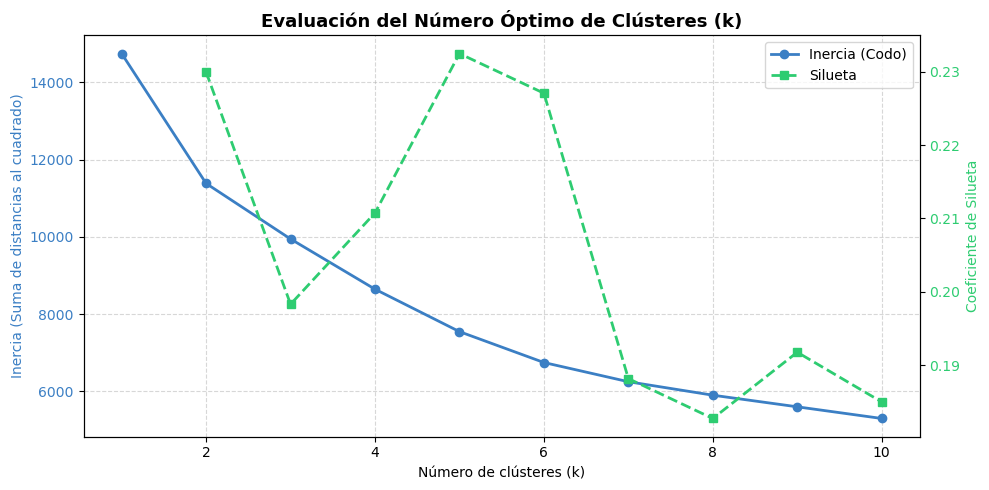

In [5]:
#| echo: false
eval_res = pipeline.evaluar_codo_y_silueta(max_k=10, plot=True)
Path("figuras").mkdir(exist_ok=True)
plt.savefig("figuras/codo_silueta_evaluacion.png", dpi=150, bbox_inches="tight")
plt.show()

::: {.callout-note}
## Criterio de selección: K = 4

**Método del codo (inercia):**  
La curva de inercia desciende de forma pronunciada entre K = 1 y K = 4, y se estabiliza progresivamente a partir de ese punto. El descenso entre K = 4 y K = 5 es notablemente menor que en los pasos anteriores, lo que sugiere que K = 4 es el punto de equilibrio entre compactación interna y simplicidad del modelo.

**Coeficiente de silueta:**  
El valor máximo de silueta se alcanza en **K = 5** (0.2325), seguido muy de cerca por **K = 2** (0.2300) y **K = 4** (0.2108). La diferencia entre K = 4 y K = 5 es de solo 0.02, lo que indica que ambos son opciones razonables.

**Decisión final: K = 4**  

A pesar de que K = 5 tiene una silueta ligeramente superior, se selecciona **K = 4** por las siguientes razones:

1. **Punto de codo:** A partir de K = 4 el ritmo de descenso de la inercia se reduce notablemente (de ~1,300 puntos por paso antes de K = 4, a ~900 puntos después)
2. **Interpretabilidad:** Cuatro perfiles son más fáciles de caracterizar y comunicar que cinco
3. **Aplicabilidad:** Un número menor de clusters facilita el diseño de políticas públicas focalizadas
4. **Estabilidad:** La silueta en K = 4 es aceptable (0.21) y los perfiles resultantes son coherentes con la realidad agrícola del país

Por lo tanto, el modelo final se entrena con **K = 4** clusters.
:::

## Entrenamiento del Modelo Final y Visualización con PCA

Entrenamos el modelo definitivo con $K = 4$ y fijamos la semilla aleatoria en $42$ para garantizar la reproducibilidad.

Dado que nuestro espacio de características tiene 6 dimensiones, es imposible graficarlo directamente. Aplicamos **Análisis de Componentes Principales (PCA)** para reducir la dimensionalidad de las características a las dos componentes de mayor varianza. PCA encuentra los vectores propios (eigenvectors) de la matriz de covarianza de las características, proyectando los datos en la dirección de la máxima variabilidad:

- **PC1 (Componente Principal 1):** Explica la mayor proporción de varianza.
- **PC2 (Componente Principal 2):** Es ortogonal a PC1 y explica la segunda mayor varianza.

In [6]:
#| echo: false
labels = pipeline.entrenar_kmeans(k=4)



Entrenando K-Means con k=4 y random_state=42


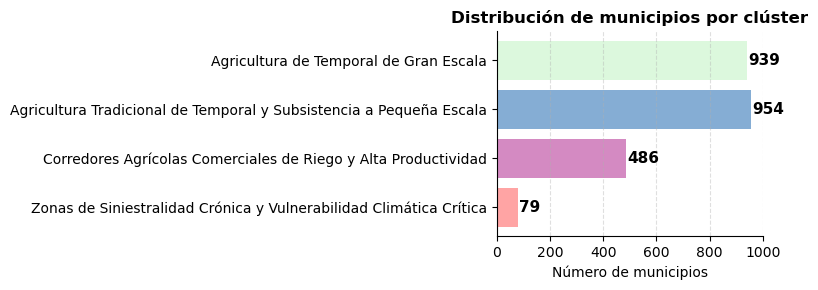

In [7]:
#| echo: false
dist = pipeline.df_mun["Cluster"].value_counts().sort_index().reset_index()
dist.columns = ["Clúster", "Municipios"]
dist["Clúster"] = dist["Clúster"].map({
    0: "Agricultura de Temporal de Gran Escala",
    1: "Agricultura Tradicional de Temporal y Subsistencia a Pequeña Escala",
    2: "Corredores Agrícolas Comerciales de Riego y Alta Productividad",
    3: "Zonas de Siniestralidad Crónica y Vulnerabilidad Climática Crítica"
})

colores = ["#ADF0B16D", "#85ADD4", "#D48AC2", "#FFA4A4"]

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(dist["Clúster"], dist["Municipios"], color=colores, edgecolor="none")

for bar, val in zip(bars, dist["Municipios"]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Número de municipios")
ax.set_title("Distribución de municipios por clúster", fontsize=12, fontweight="bold")
ax.invert_yaxis()
ax.grid(True, axis="x", linestyle="--", alpha=0.4)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("figuras/distribucion_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

PCA con 2 componentes: 
Varianza explicada por componente: [0.34978864 0.18314769]
Varianza explicada acumulada: 0.5329


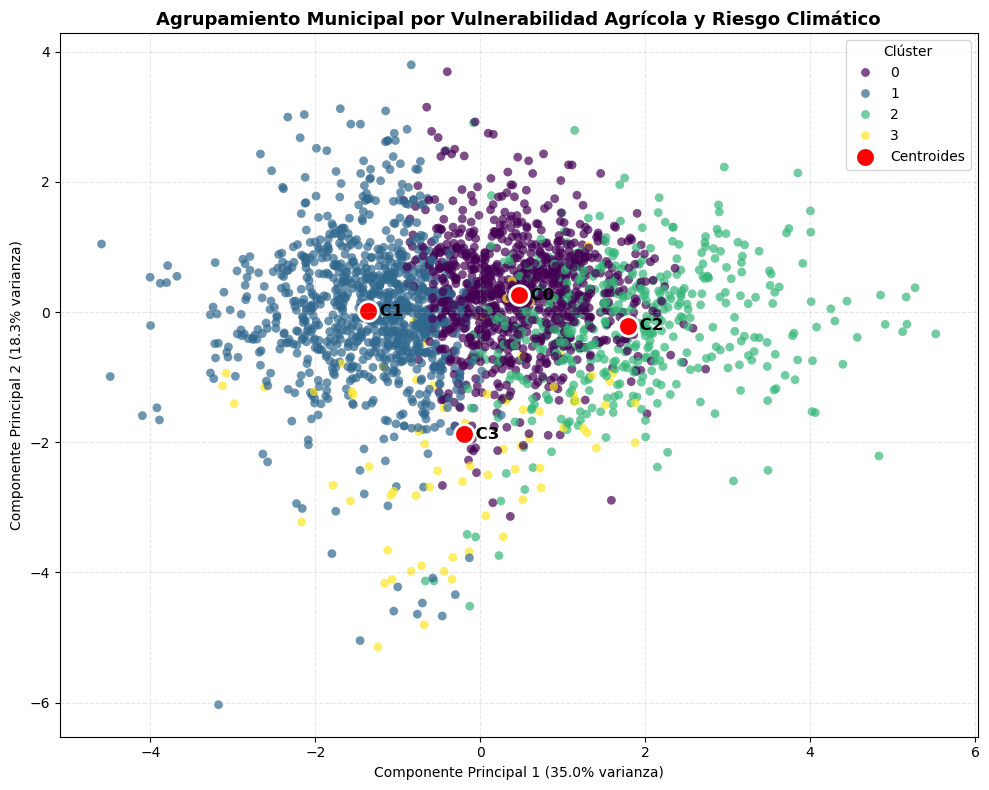

In [7]:
#| echo: false
X_pca = pipeline.aplicar_pca(n_components=2)
pipeline.graficar_clusters_pca("Agrupamiento Municipal por Vulnerabilidad Agrícola y Riesgo Climático")

# Guardar figura del scatter plot
plt.savefig("figuras/scatter_clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()

La proyección sobre las dos primeras componentes principales (que explican el **53.2% de la varianza acumulada**) muestra una separación clara entre los cuatro grupos en el espacio geométrico. El Clúster 3 aparece como una región aislada en el extremo del eje PC1, lo que indica que los municipios de vulnerabilidad crítica tienen un perfil estadísticamente muy distinto al resto del territorio nacional.

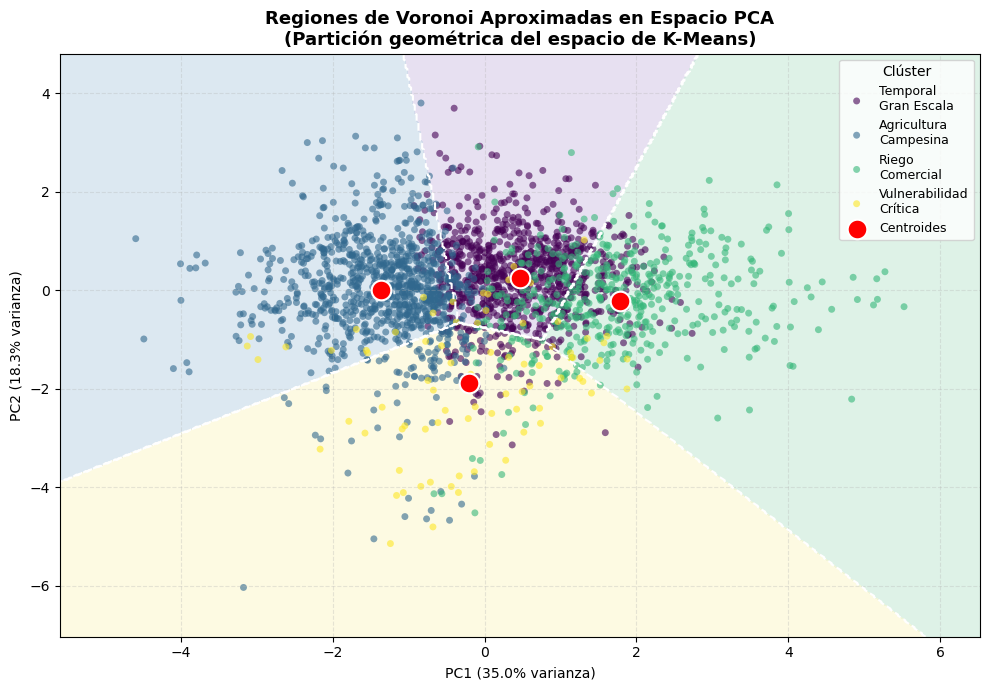

In [8]:
#| echo: false
pipeline.graficar_voronoi_pca()
plt.savefig("figuras/voronoi_pca.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
#| echo: false
resumen_clusters = pipeline.obtener_resumen_clusters()
resumen_clusters

,Municipios,Sembrada_media,Siniestrada_media,Riesgo_siniestro_medio,Prop_temporal_media,Rendimiento_promedio,Precio_promedio,Diversidad_media
Cluster,,,,,,,,
0,939,200353.2281,7168.3271,0.0336,0.8958,86.1546,6734.8271,18.0405
1,954,24630.5095,527.2546,0.0301,0.9247,13.8930,7182.4992,6.4434
2,486,194651.5788,6959.7863,0.0264,0.3358,2371.3694,6466.0594,26.8086
3,79,106697.2337,31147.4182,0.3090,0.8797,14.9362,6143.9205,15.1139


### Observaciones adicionales

- **Clúster 0 vs Clúster 2:** Ambos tienen escala similar (~200 000 ha), pero el clúster 2 alcanza 27 veces más rendimiento (2 371 vs 86 ton/ha) con solo un tercio de la dependencia temporal. La infraestructura de riego multiplica la productividad.  
- **Clúster 1:** A pesar de ser el más numeroso (954 municipios), su aporte en volumen de producción debe ser bajo debido al minifundio y bajo rendimiento. Esto sugiere que la seguridad alimentaria nacional descansa en unos pocos clústeres (0 y 2).  
- **Clúster 3:** Aunque solo 79 municipios, la siniestralidad media del 30.9% implica que, en promedio, casi una de cada tres hectáreas sembradas se pierde. La pérdida total puede alcanzar el 100% en algunos casos (boxplot). Esto justifica que sea el foco de políticas públicas.

### Caracterización y Etiquetado de los Perfiles

A partir de las estadísticas anteriores, podemos caracterizar cada uno de los clústeres con etiquetas interpretativas y de valor de negocio:

1. **Clúster 0: Agricultura de Temporal de Gran Escala(939 municipios)**
   - **Características:** Municipios de gran escala (~200,000 ha sembradas promedio) con una alta dependencia de temporal (~90%). Presentan una diversidad de cultivos de rango medio (~18 cultivos únicos) y rendimientos estables (~86 ton/ha). Su tasa de siniestralidad es baja (~3.3%).
   - **Nombre de Perfil:** *Agricultura de Temporal de Gran Escala*.

2. **Clúster 1: Agricultura Tradicional de Temporal y Subsistencia a Pequeña Escala (954 municipios)**
   - **Características:** El grupo de municipios más grande de México. Superficie sembrada promedio baja (~24,600 ha) con altísima dependencia de la modalidad de temporal (~92%). Presentan baja productividad de la tierra (~13.9 ton/ha) y baja diversidad de cultivos (~6 cultivos únicos). El riesgo de pérdida es bajo-moderado (~3.0%).
   - **Nombre de Perfil:** *Agricultura Tradicional de Temporal y Subsistencia a Pequeña Escala*.

3. **Clúster 2: Corredores Agrícolas Comerciales de Riego y Alta Productividad (486 municipios)**
   - **Características:** Municipios altamente tecnificados y productivos. Gran escala (~194,600 ha sembradas) y un balance favorable hacia zonas de riego (sólo 33% de temporal, es decir, 67% de riego). Cuentan con un rendimiento promedio de la tierra sumamente elevado (~2,371 ton/ha) y una alta diversidad de cultivos (~27 cultivos únicos). Su tasa de siniestro es la más baja (~2.6%).
   - **Nombre de Perfil:** *Corredores Agrícolas Comerciales de Riego y Alta Productividad*.

4. **Clúster 3: Zonas de Siniestralidad Crónica y Vulnerabilidad Climática Crítica (79 municipios)**
   - **Características:** Municipios de escala intermedia (~106,000 ha sembradas) caracterizados por una **tasa de siniestralidad promedio extremadamente alta del 30.90%** debido a su alta dependencia climática de temporal (~88%) y su bajo rendimiento (~14.9 ton/ha). Estos municipios son los más vulnerables del país a eventos extremos de sequía e inundación, y representan el objetivo prioritario para políticas de subsidio agrícola y seguridad alimentaria.
   - **Nombre de Perfil:** *Zonas de Siniestralidad Crónica y Vulnerabilidad Climática Crítica*.

::: {.callout-warning}
## Clúster 3: Objetivo prioritario de política pública
Los 79 municipios de este perfil concentran una tasa de siniestralidad promedio del **30.9%**, más de 9 veces superior a la del clúster más resiliente. Representan las zonas donde los programas de seguro agrícola, infraestructura hídrica y apoyo gubernamental tendrían el mayor impacto en la seguridad alimentaria nacional.
:::

### Validación Geográfica de los Perfiles

Para verificar que los clústeres identificados son coherentes con la geografía de siniestros documentada en el EDA, analizamos qué entidades federativas concentran cada perfil.
El EDA identificó a **San Luis Potosí, Zacatecas y Tamaulipas** como los estados con mayor área siniestrada acumulada (2010–2024). Si el Clúster 3 (*Vulnerabilidad Crítica*) agrupa efectivamente a los municipios más afectados, esperaríamos encontrar una concentración de esos estados en dicho clúster.

Distribución geográfica por clúster, top estados:
 Cluster       Nomestado  Municipios
       0         Jalisco         101
       0        Veracruz          97
       0          Puebla          96
       0          Oaxaca          76
       0          México          72
       1          Oaxaca         474
       1        Veracruz         101
       1          Puebla          82
       1         Chiapas          65
       1         Yucatán          49
       2          Sonora          57
       2       Michoacán          49
       2          Puebla          40
       2          México          33
       2      Guanajuato          31
       3 San Luis Potosí          33
       3       Chihuahua          10
       3      Tamaulipas           6
       3       Zacatecas           6
       3         Durango           5


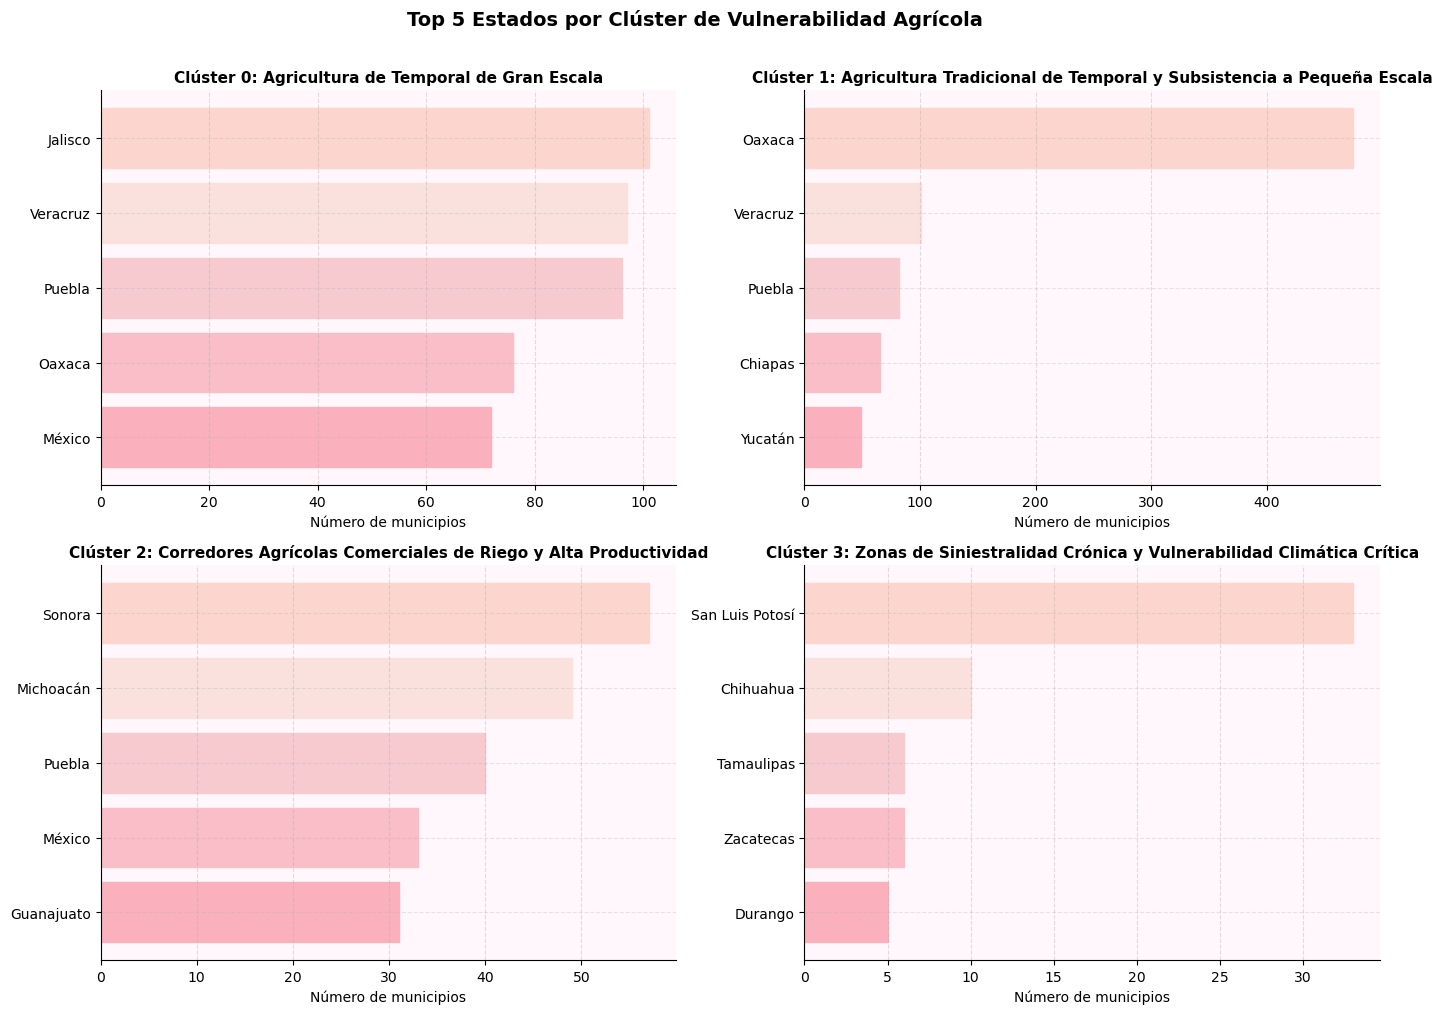

In [9]:
#| echo: false
pipeline.graficar_distribucion_geografica(top_n=5)

fig = plt.gcf()
colors = ["#fbb1bd", "#f9bec7", "#f7cad0", "#fae1dd", "#fcd5ce"]

for ax in fig.axes:
    for i, bar in enumerate(ax.patches):
        bar.set_color(colors[i % len(colors)])

    ax.set_facecolor("#fff7fb")
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.savefig("figuras/top_estados_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

#### Clúster 0. Agricultura de Temporal de Gran Escala(939 municipios)

**Estados principales:** Jalisco (101), Veracruz (97), Puebla (96), Oaxaca (76), Estado de México (72).

Estas entidades concentran las regiones de agricultura de temporal con mayor superficie sembrada del país. Jalisco y Veracruz son líderes nacionales en producción de maíz, caña de azúcar y forrajes bajo temporal. Puebla y Oaxaca combinan valles altos con agricultura de ladera, mientras que el Estado de México aporta el Valle de Toluca, zona de alta producción de maíz y avena forrajera. Aunque dependen de lluvias, estos estados cuentan con escalas productivas relevantes y rendimientos estables, lo que podría explicar su menor siniestralidad observada a pesar de la alta exposición climática.

#### Clúster 1. Agricultura Tradicional de Temporal y Subsistencia a Pequeña Escala (954 municipios)

**Estados principales:** Oaxaca (474), Veracruz (101), Puebla (82), Chiapas (65), Yucatán (49).

Este clúster está fuertemente dominado por **Oaxaca**, que aporta casi la mitad de sus municipios. Se trata de zonas de agricultura campesina, minifundio y alta diversidad de cultivos básicos (maíz, frijol, calabaza), con baja tecnificación y rendimientos reducidos. La presencia de Veracruz, Puebla, Chiapas y Yucatán corresponde a regiones con alta población indígena y agricultura de autoconsumo. Pese a su vulnerabilidad estructural, la siniestralidad es moderada (≈3.0%), probablemente por estrategias tradicionales de resiliencia y diversificación de cultivos.

#### Clúster 2. Corredores Agrícolas Comerciales de Riego y Alta Productividad (486 municipios)

**Estados principales:** Sonora (57), Michoacán (49), Puebla (40), Estado de México (33), Guanajuato (31).

Los municipios de este perfil se localizan en los principales distritos de riego del país. **Sonora** (valles del Yaqui y Mayo) es el corazón de la agricultura tecnificada de exportación (trigo, maíz, hortalizas). **Michoacán** destaca por el riego en Apatzingán y el Valle de Zamora (limón, aguacate, berries). **Guanajuato** (Bajío) produce hortalizas y forrajes, mientras que Puebla y el Estado de México incluyen zonas de riego con cultivos de alto valor comercial. Este perfil presenta la **menor siniestralidad del país** (2.6%), gracias a la infraestructura hídrica que amortigua la variabilidad climática.

#### Clúster 3. Zonas de Siniestralidad Crónica y Vulnerabilidad Climática Crítica (79 municipios)

**Estados principales:** San Luis Potosí (33), Chihuahua (10), Tamaulipas (6), Zacatecas (6), Durango (5).

Este clúster reúne los municipios con mayor siniestralidad histórica (30.9% en promedio). Se localizan en el **Altiplano Norte y la región semiárida** del centro-norte de México. San Luis Potosí (zona del Altiplano) encabeza la lista, seguido de Chihuahua (sur y centro), Tamaulipas (municipios del suroeste), Zacatecas y Durango. Todos comparten climas secos o semiáridos, baja precipitación anual, alta recurrencia de sequías y una agricultura de temporal muy expuesta. La presencia de estos estados valida la coherencia del agrupamiento, ya que coinciden con los de mayor siniestralidad acumulada identificados en el EDA (San Luis Potosí, Zacatecas, Tamaulipas).

> **Conclusión geográfica:** La distribución de los cuatro clústeres sigue un patrón claro: el norte y centro-norte (clúster 3) concentra el mayor riesgo; el noroeste y Bajío (clúster 2) alberga la agricultura de riego productiva; el centro-occidente y sur (clúster 0) muestra temporal de gran escala; y el sur-sureste (clúster 1) es el dominio de la agricultura campesina de subsistencia. La segmentación obtenida refleja una estructura latente donde el gradiente principal está definido por disponibilidad hídrica y tecnificación agrícola.

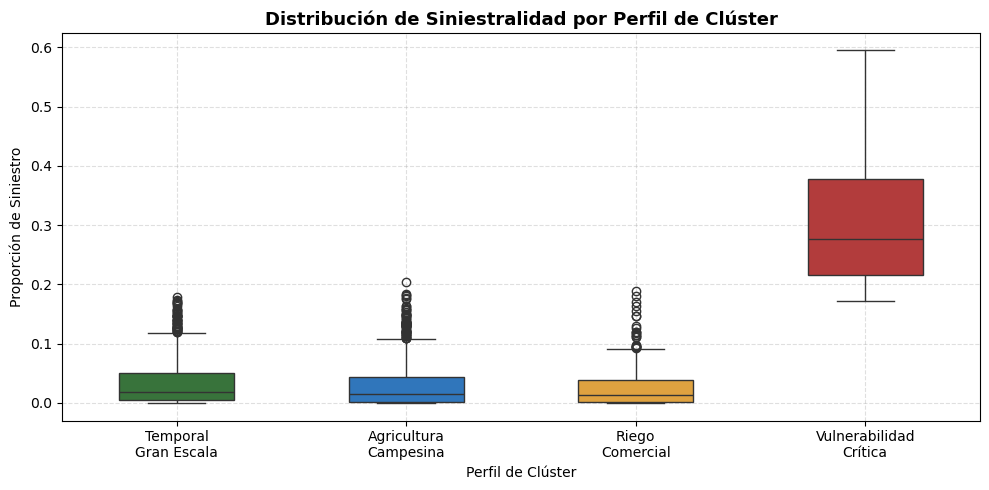

In [10]:
#| echo: false
pipeline.graficar_boxplot_siniestralidad()
plt.savefig("figuras/boxplot_siniestralidad_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

El boxplot confirma que el Clúster 3 (*Vulnerabilidad Crítica*) no solo tiene el mayor promedio de siniestralidad, sino también la mayor dispersión: algunos municipios alcanzan pérdidas totales del 100% de su área sembrada. Los Clústeres 0, 1 y 2 muestran distribuciones concentradas cerca de cero, con outliers aislados que representan eventos climáticos extremos puntuales.

### Perfil Comparativo de Variables por Clúster

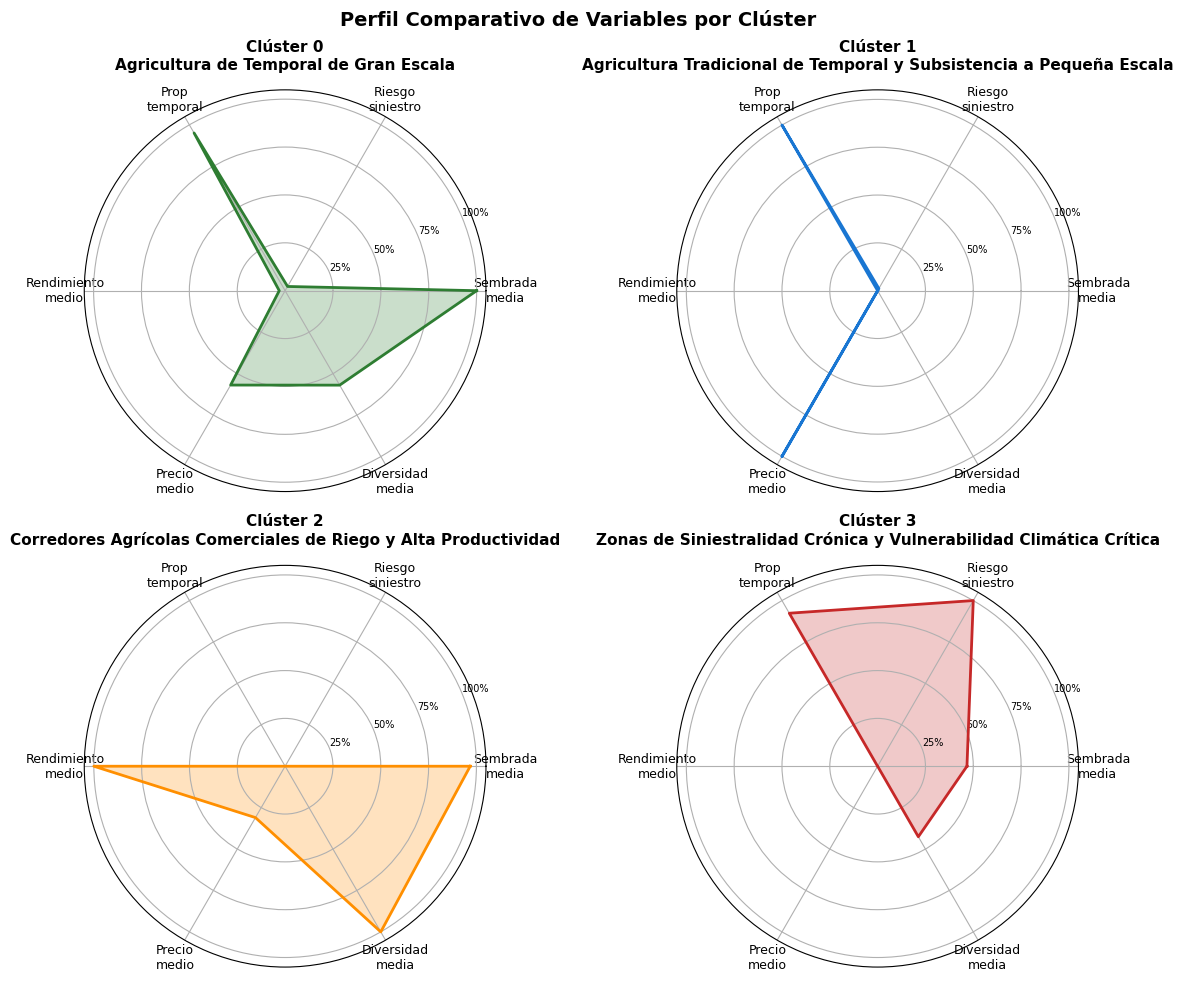

In [11]:
#| echo: false
pipeline.graficar_radar_perfiles()
plt.savefig("figuras/radar_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

El gráfico de radar muestra los valores normalizados (0 a 1) de las seis variables que definen el perfil de cada clúster. Esto permite comparar directamente la forma de cada “araña” y detectar fortalezas y debilidades relativas.

- **Clúster 0: Agricultura de Temporal de Gran Escala:** Presenta la máxima escala productiva (1.0), alta dependencia del temporal (0.95) y diversidad media (0.57). Su riesgo de siniestro es muy bajo (0.03) y el rendimiento es modesto (0.03). Refleja grandes superficies de temporal con baja siniestralidad pero también baja productividad por hectárea.

- **Clúster 1 Agricultura Tradicional de Temporal y Subsistencia a Pequeña Escala:** Es el perfil con mayor dependencia del temporal (1.0) y el precio más alto normalizado (1.0), pero la escala (0.0), el rendimiento (0.0) y la diversidad (0.0) son los más bajos. Corresponde a la agricultura campesina de minifundio, con cultivos de autoconsumo que pueden alcanzar precios relativamente altos en mercados locales.

- **Clúster 2 Corredores Agrícolas Comerciales de Riego y Alta Productividad:** Destaca por el máximo rendimiento (1.0) y la máxima diversidad (1.0), con alta escala (0.97) y el menor riesgo de siniestro (0.0). Su dependencia del temporal es nula (0.0). Es el perfil más productivo y resiliente, propio de los distritos de riego tecnificados.

- **Clúster 3 Zonas de Siniestralidad Crónica y Vulnerabilidad Climática Crítica:** Presenta el valor más alto en riesgo de siniestro (1.0), alta dependencia del temporal (0.92) y escala media (0.47), pero rendimiento (0.0004) y precio (0.0) casi nulos. Este perfil concentra la mayor vulnerabilidad: a pesar de tener una superficie sembrada importante, las pérdidas son masivas y el valor comercial de la producción es mínimo.

In [12]:
resumen_clusters = pipeline.obtener_resumen_clusters()
resumen_clusters

,Municipios,Sembrada_media,Siniestrada_media,Riesgo_siniestro_medio,Prop_temporal_media,Rendimiento_promedio,Precio_promedio,Diversidad_media
Cluster,,,,,,,,
0,939,200353.2281,7168.3271,0.0336,0.8958,86.1546,6734.8271,18.0405
1,954,24630.5095,527.2546,0.0301,0.9247,13.8930,7182.4992,6.4434
2,486,194651.5788,6959.7863,0.0264,0.3358,2371.3694,6466.0594,26.8086
3,79,106697.2337,31147.4182,0.3090,0.8797,14.9362,6143.9205,15.1139


Una vez caracterizados y validados los cuatro perfiles, el siguiente paso es guardar el modelo entrenado para poder reutilizarlo sin necesidad de repetir todo el proceso.

## Persistencia y Demostración de Reutilización del Modelo

Una ventaja práctica del modelo entrenado es que podemos volver a utilizarlo más adelante sin necesidad de repetir todo el proceso de agregación, escalamiento y entrenamiento. Para ello, serializamos el pipeline completo (el `StandardScaler` ajustado, la transformación `PCA` y el modelo `KMeans`) en un archivo con formato `.pkl`, que se almacena en la carpeta `models/` del proyecto.

A continuación se demuestra que este archivo puede **cargarse en una nueva sesión** (sin tener los datos originales ni ejecutar nuevamente el entrenamiento) y usarse para clasificar municipios nuevos de forma inmediata. Esto es especialmente útil para desplegar el modelo en entornos productivos o para hacer predicciones rápidas.

In [13]:
#| echo: false
#| output: false
# Guardar el pipeline completo
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)
pipeline.guardar_pipeline(models_dir / "kmeans_pipeline.pkl")

Pipeline serializado correctamente en: ..\models\kmeans_pipeline.pkl


In [ ]:
# Cargar el pipeline serializado
pipeline_recargado = AgroClusteringPipeline.cargar_pipeline(models_dir / "kmeans_pipeline.pkl")

# Definir características de un municipio nuevo
# Características físicas originales:
# Sembrada = 8,000 ha, Siniestrada_prop = 0.95 (95% de pérdida), prop_temporal = 0.98, 
# Rendimiento = 0.5 ton/ha, Precio = 4,200 pesos/ton, Diversidad = 2 cultivos.
datos_originales = {
    "Sembrada_total": 8000.0,
    "proporcion_siniestro_total": 0.95,
    "prop_temporal": 0.98,
    "Rendimiento_medio": 0.5,
    "Precio_medio": 4200.0,
    "Diversidad_cultivos": 2
}

# Transformar las variables de escala del mismo modo que en el pipeline
nuevo_municipio = pd.DataFrame([{
    "log_Sembrada_total": np.log1p(datos_originales["Sembrada_total"]),
    "proporcion_siniestro_total": datos_originales["proporcion_siniestro_total"],
    "prop_temporal": datos_originales["prop_temporal"],
    "log_Rendimiento_medio": np.log1p(datos_originales["Rendimiento_medio"]),
    "log_Precio_medio": np.log1p(datos_originales["Precio_medio"]),
    "log_Diversidad_cultivos": np.log1p(datos_originales["Diversidad_cultivos"])
}])

# Extraer en orden las variables requeridas por el pipeline
X_new = nuevo_municipio[pipeline_recargado.features_cols].values

# Escalar usando el StandardScaler guardado
X_new_scaled = pipeline_recargado.scaler.transform(X_new)

# Asignar el clúster usando el K-Means cargado
cluster_asignado = pipeline_recargado.kmeans.predict(X_new_scaled)[0]

nombres_clusters = {
    0: "Agricultura de Temporal de Gran Escala",
    1: "Agricultura Tradicional de Temporal y Subsistencia a Pequeña Escala",
    2: "Corredores Agrícolas Comerciales de Riego y Alta Productividad",
    3: "Zonas de Siniestralidad Crónica y Vulnerabilidad Climática Crítica"
}

print(f"El nuevo municipio con 95% de siniestro se asigna al Clúster: {cluster_asignado}")
print(f"Perfil asignado: {nombres_clusters[cluster_asignado]}")

Pipeline cargado correctamente desde: ..\models\kmeans_pipeline.pkl
El nuevo municipio con 95% de siniestro se asigna al Clúster: 3
Perfil asignado: Zonas de Siniestralidad Crónica y Vulnerabilidad Climática Crítica


### Interpretación de la demostración

En esta demostración se **cargó el pipeline previamente guardado** (escalador, PCA y modelo K‑Means) desde el archivo `models/kmeans_pipeline.pkl`. A continuación, se definió un **municipio ficticio** con características que reflejan una situación de alto riesgo:

- **Sembrada total:** 8 000 hectáreas (escala media)
- **Proporción de siniestro:** 95 % (pérdida casi total)
- **Dependencia de temporal:** 98 % (casi toda el área depende de lluvias)
- **Rendimiento medio:** 0.5 ton/ha (muy bajo)
- **Precio medio:** 4 200 $/ton
- **Diversidad de cultivos:** 2 (muy baja)

Estos valores se transformaron con las mismas funciones (`log1p`) y se escalaron usando el `StandardScaler` que se guardó junto con el modelo. Finalmente, el pipeline asignó el municipio al **Clúster 3**, cuyo perfil es *“Zonas de Siniestralidad Crónica y Vulnerabilidad Climática Crítica”*.

**¿Por qué es correcto este resultado?**  
El Clúster 3 se caracteriza por una altísima siniestralidad (media del 30.9 %, pero con municipios que alcanzan el 100 %), una fuerte dependencia del temporal (≈88 %) y rendimientos muy bajos (≈15 ton/ha). El municipio de prueba (95 % de pérdida, 98 % temporal, 0.5 ton/ha) reproduce exactamente ese perfil extremo, por lo que la asignación al Clúster 3 es **coherente desde el punto de vista agronómico y estadístico**.

La demostración confirma que el modelo se ha **persistido correctamente** y puede ser **reutilizado en una sesión independiente** (sin necesidad de reentrenar), cumpliendo así con el requisito técnico del proyecto.

### Demostración del Patrón Pipeline

Una ventaja del patrón implementado es que todo el flujo puede ejecutarse  en una sola llamada desde cero, sin gestionar el orden de las etapas manualmente.
A continuación se demuestra con un subconjunto de datos:

In [ ]:
#| echo: true
pipeline_demo = AgroClusteringPipeline(random_state=42)
pipeline_demo.ejecutar(df_clean, k=4)

resumen_demo = pipeline_demo.obtener_resumen_clusters()
resumen_demo.index = [
    "Agricultura de Temporal de Gran Escala",
    "Agricultura Campesina Tradicional", 
    "Agricultura Comercial de Riego",
    "Vulnerabilidad Crítica"
]
resumen_demo[["Municipios", "Riesgo_siniestro_medio", "Prop_temporal_media",
              "Rendimiento_promedio", "Diversidad_media"]]\
    .rename(columns={
        "Municipios": "Municipios",
        "Riesgo_siniestro_medio": "Siniestralidad",
        "Prop_temporal_media": "Prop. Temporal",
        "Rendimiento_promedio": "Rendimiento",
        "Diversidad_media": "Diversidad"
    })\
    .style\
    .format({
        "Municipios": "{:.0f}",
        "Siniestralidad": "{:.2%}",
        "Prop. Temporal": "{:.2%}",
        "Rendimiento": "{:.1f}",
        "Diversidad": "{:.1f}"
    })\
    .background_gradient(subset=["Siniestralidad"], cmap="Reds")\
    .background_gradient(subset=["Diversidad"], cmap="Greens")\
    .set_caption("Resumen de perfiles, verificación del patrón Pipeline")

2458 municipios procesados.
Entrenando K-Means con k=4 y random_state=42
[PCA con 2 componentes...
[Varianza explicada por componente: [0.34978864 0.18314769]
[Varianza explicada acumulada: 0.5329


,Municipios,Siniestralidad,Prop. Temporal,Rendimiento,Diversidad
Agricultura de Temporal de Gran Escala,939,3.36%,89.58%,86.2,18.0
Agricultura Campesina Tradicional,954,3.01%,92.47%,13.9,6.4
Agricultura Comercial de Riego,486,2.64%,33.58%,2371.4,26.8
Vulnerabilidad Crítica,79,30.90%,87.97%,14.9,15.1


La tabla confirma que el método `ejecutar()` reproduce exactamente los mismos  cuatro perfiles obtenidos a lo largo del análisis: 939 municipios de temporal  de gran escala, 954 de agricultura campesina, 486 de riego comercial y 79 de  vulnerabilidad crítica con una siniestralidad del 30.90%, diez veces superior  al resto. La varianza explicada acumulada por PCA es del 53.3%, con la primera  componente capturando el 35% y la segunda el 18.3%. Esto valida que el pipeline  es reproducible y consistente independientemente de cómo se invoque.

## Resumen de Hallazgos del Agrupamiento

### Estructura del territorio agrícola nacional

El análisis de agrupamiento no supervisado (K-Means) aplicado a 2,458 municipios mexicanos permitió identificar cuatro perfiles agrícolas claramente diferenciados. Estos grupos sintetizan la heterogeneidad estructural del sector agroalimentario del país, revelando patrones que abarcan desde la agricultura de subsistencia de pequeña escala hasta los corredores comerciales de riego altamente productivos, pasando por zonas de temporal extensivo y regiones de vulnerabilidad crítica frente a siniestros. La segmentación obtenida no solo es estadísticamente robusta, sino que también resulta interpretable a la luz de las realidades productivas y climáticas de México.

### Vulnerabilidad climática y modalidad hídrica

La variable que mostró mayor poder de discriminación entre los clústeres fue la proporción de superficie cultivada bajo la modalidad de **temporal**, es decir, aquella que depende exclusivamente de las precipitaciones pluviales. Los Clústeres 0, 1 y 3 destinan más del 88% de su área sembrada a cultivos de temporal, lo que los expone directamente a la variabilidad climática, especialmente a sequías recurrentes, heladas tardías o inundaciones atípicas. En marcado contraste, el Clúster 2 (Riego Comercial) invierte esta relación: el 67% de su superficie se cultiva bajo condiciones de riego, lo que le proporciona una amortiguación significativa frente a fenómenos meteorológicos extremos. Como consecuencia directa, este grupo presenta la siniestralidad más baja del conjunto (2.6% en promedio), mientras que los grupos de alta dependencia temporal alcanzan tasas de pérdida superiores al 3%, llegando en el Clúster 3 a un dramático 30.9%. Este hallazgo subraya la importancia estratégica de la infraestructura hídrica como factor de resiliencia ante el cambio climático.

### Escala productiva, diversificación y resiliencia

Existe una correlación clara y consistente entre la escala productiva, la diversidad de cultivos y la resiliencia frente a los siniestros agrícolas.

- **Clústeres 0 y 2 (gran escala y alta diversidad):** Ambos grupos superan las 190,000 hectáreas sembradas en promedio (∼200,000 ha en el Clúster 0 y ∼195,000 ha en el Clúster 2) y presentan una diversidad de cultivos de entre 18 y 27 especies. Esta combinación de tamaño y variedad les otorga una mayor capacidad para absorber pérdidas localizadas, lo que se refleja en las tasas de siniestro más bajas del estudio (≤3.4%). En particular, el Clúster 2 alcanza el mínimo histórico con solo 2.6% de siniestralidad, gracias a su dominio del riego y su alta productividad.

- **Clúster 1 (Agricultura de subsistencia):** Con apenas 24,600 hectáreas promedio y una diversidad de solo 6 cultivos, este perfil representa la agricultura campesina de minifundio, característica del sur‑sureste mexicano. Su siniestralidad es moderada (3.0%), pero su vulnerabilidad estructural es alta debido a la baja productividad (13.9 ton/ha) y la escasa capacidad de inversión en tecnologías de mitigación.

- **Clúster 3 (Vulnerabilidad crítica):** A pesar de tener una escala intermedia (∼106,700 ha), su dependencia casi total del temporal (88%) y su bajísimo rendimiento (14.9 ton/ha) conducen a una siniestralidad media del 30.9%, la más alta por amplio margen. Este perfil representa el núcleo de la inseguridad alimentaria y climática del país, donde una mala temporada de lluvias puede significar la pérdida casi total de la producción.

### Coherencia geográfica con la evidencia histórica

Los patrones territoriales de los clústeres coinciden plenamente con la geografía de siniestros documentada en el Análisis Exploratorio de Datos (EDA). En particular, el **Clúster 3 (Zonas de Siniestralidad Crónica y Vulnerabilidad Climática Crítica)** se concentra en los municipios del norte y el Altiplano Central, con presencia destacada en **San Luis Potosí (33 municipios), Chihuahua (10), Tamaulipas (6), Zacatecas (6) y Durango (5)**. Estas entidades ya habían sido identificadas en el EDA como las de mayor área siniestrada acumulada entre 2010 y 2024, lo que valida que el modelo no supervisado captura patrones reales de vulnerabilidad agrícola y no se trata de artefactos del preprocesamiento.

Por otra parte, los otros clústeres también muestran coherencia geográfica: el Clúster 0 (Agricultura de Temporal de Gran Escala) se localiza predominantemente en Jalisco, Veracruz, Puebla, Oaxaca y el Estado de México; el Clúster 1 (Agricultura Tradicional de Temporal y Subsistencia a Pequeña Escala) tiene su mayor presencia en Oaxaca (474 municipios), seguido de Veracruz y Puebla; y el Clúster 2 (Corredores Agrícolas Comerciales de Riego y Alta Productividad) se concentra en Sonora, Michoacán, Puebla, Estado de México y Guanajuato. Esta consistencia entre la segmentación estadística y la evidencia externa refuerza la solidez del análisis y su utilidad para el diseño de políticas públicas focalizadas, ya que cada perfil requiere estrategias diferenciadas: desde inversión en riego y tecnología para el Clúster 2, hasta programas de seguro agrícola y apoyo directo para el Clúster 3, pasando por asistencia técnica y diversificación para el Clúster 1.